# 🎵 Quá Trình Truy Vấn Tìm Kiếm Âm Thanh (Audio Search Query Process)

## Tổng Quan
Notebook này mô tả toàn bộ quy trình xử lý khi người dùng tải lên một file âm thanh:
1. **Waveform**: Biểu diễn sóng âm thanh gốc
2. **Spectrogram**: Phân tích tần số theo thời gian
3. **Feature Vector**: Trích xuất 19 đặc trưng (MFCC, Spectral, Energy...)
4. **Cosine Similarity**: Tính độ tương đồng với các file trong CSDL

---

## 6.4.1 Waveform - Biểu Diễn Sóng Âm Thanh

In [2]:
import os
import sys
import csv
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Các thư viện đã được import thành công!")

✅ Các thư viện đã được import thành công!


In [3]:
# Cấu hình
DATA_TRAIN_DIR = "/Users/nangvuong/Desktop/BTL_CSDLDPT/audio-feature-extractor/Data_Test"

# Chọn một file âm thanh từ training data để demo
sample_file = os.path.join(DATA_TRAIN_DIR, "violin", "007__[vio][nod][cla]2103__1.wav")

# Load audio file
print(f"📂 Loading: {sample_file}")
y, sr = librosa.load(sample_file, sr=22050)

print(f"✅ Audio loaded successfully!")
print(f"   - Sample rate: {sr} Hz")
print(f"   - Duration: {len(y)/sr:.2f} seconds")
print(f"   - Shape: {y.shape}")

📂 Loading: /Users/nangvuong/Desktop/BTL_CSDLDPT/audio-feature-extractor/Data_Test/violin/007__[vio][nod][cla]2103__1.wav
✅ Audio loaded successfully!
   - Sample rate: 22050 Hz
   - Duration: 3.00 seconds
   - Shape: (66150,)


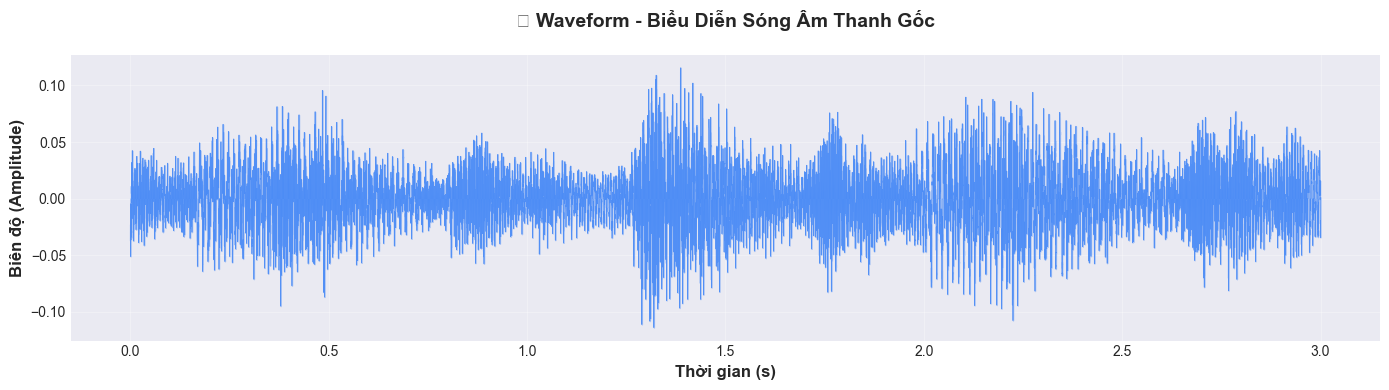

✅ Waveform hiển thị thành công!
   📊 Biên độ min: -0.1142, max: 0.1157
   📊 RMS Energy: 0.0240


In [4]:
# Vẽ Waveform
fig, ax = plt.subplots(figsize=(14, 4))

time_axis = np.arange(len(y)) / sr

ax.plot(time_axis, y, linewidth=0.5, alpha=0.8, color='#3B82F6')
ax.fill_between(time_axis, y, alpha=0.3, color='#3B82F6')
ax.set_xlabel('Thời gian (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Biên độ (Amplitude)', fontsize=12, fontweight='bold')
ax.set_title('🎧 Waveform - Biểu Diễn Sóng Âm Thanh Gốc', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Waveform hiển thị thành công!")
print(f"   📊 Biên độ min: {y.min():.4f}, max: {y.max():.4f}")
print(f"   📊 RMS Energy: {np.sqrt(np.mean(y**2)):.4f}")

## 6.4.2 Spectrogram - Phân Tích Tần Số Theo Thời Gian

✅ Spectrogram tính toán thành công!
   - Shape: (128, 130) (128 mel-bins × time-steps)
   - Min dB: -80.00, Max dB: 0.00


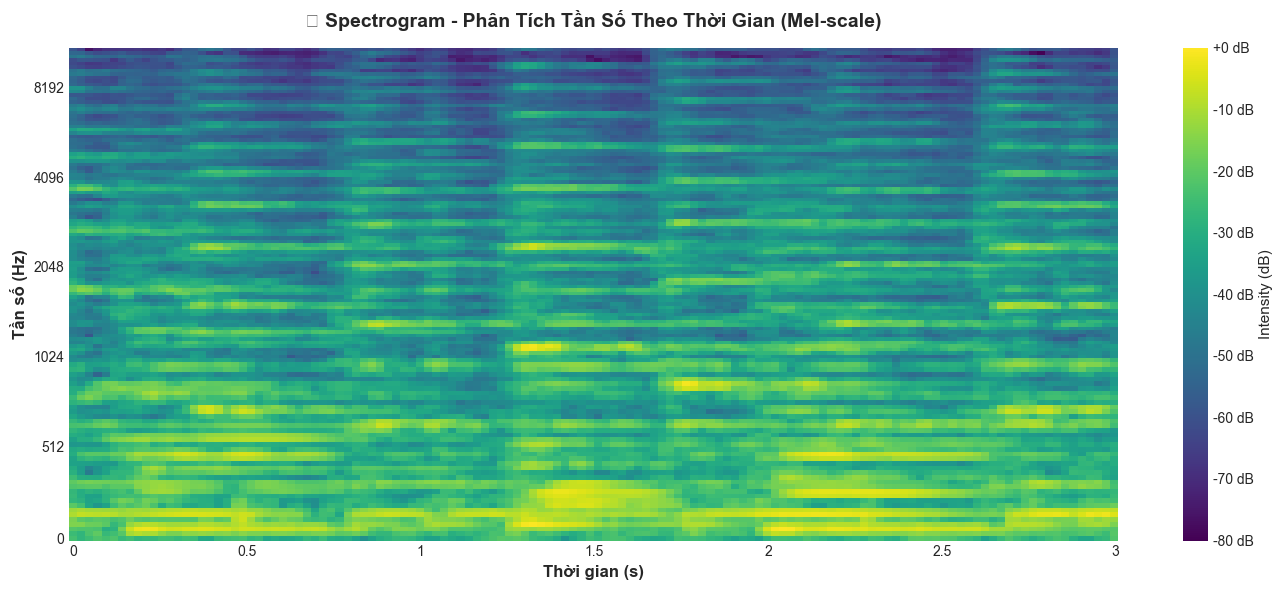

In [5]:
# Tính Spectrogram (STFT)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

print(f"✅ Spectrogram tính toán thành công!")
print(f"   - Shape: {S_dB.shape} (128 mel-bins × time-steps)")
print(f"   - Min dB: {S_dB.min():.2f}, Max dB: {S_dB.max():.2f}")

# Vẽ Spectrogram
fig, ax = plt.subplots(figsize=(14, 6))

img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap='viridis')
ax.set_title('🎼 Spectrogram - Phân Tích Tần Số Theo Thời Gian (Mel-scale)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Thời gian (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tần số (Hz)', fontsize=12, fontweight='bold')

cbar = plt.colorbar(img, ax=ax, format='%+2.0f dB')
cbar.set_label('Intensity (dB)', fontsize=11)

plt.tight_layout()
plt.show()

## 6.4.3 Vector Đặc Trưng - Trích Xuất 19 Đặc Trưng Âm Thanh

In [6]:
FEATURE_NAMES = (
    [f"mfcc_{i + 1}" for i in range(13)]
    +
    [
        "spectral_centroid",
        "spectral_bandwidth",
        "spectral_rolloff",
        "zero_crossing_rate",
        "rms_energy",
        "spectral_contrast"
    ]
)

# Trích xuất các đặc trưng
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc_mean = np.mean(mfcc, axis=1)

centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
centroid_mean = np.mean(centroid)

bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
bandwidth_mean = np.mean(bandwidth)

rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
rolloff_mean = np.mean(rolloff)

zcr = librosa.feature.zero_crossing_rate(y)
zcr_mean = np.mean(zcr)

rms = librosa.feature.rms(y=y)
rms_mean = np.mean(rms)

contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
contrast_mean = np.mean(contrast)

# Ghép thành vector 19 chiều
raw_feature_vector = np.concatenate([
    mfcc_mean,  # 13 dims
    [centroid_mean],  # 1 dim
    [bandwidth_mean],  # 1 dim
    [rolloff_mean],  # 1 dim
    [zcr_mean],  # 1 dim
    [rms_mean],  # 1 dim
    [contrast_mean]  # 1 dim
])

print("✅ Trích xuất 19 đặc trưng thành công!")
print(f"   - Vector shape: {raw_feature_vector.shape}")
print(f"\n📋 Giá Trị Đặc Trưng (Raw):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"   {i+1:2d}. {name:25s} = {raw_feature_vector[i]:12.6f}")

✅ Trích xuất 19 đặc trưng thành công!
   - Vector shape: (19,)

📋 Giá Trị Đặc Trưng (Raw):
    1. mfcc_1                    =  -322.361603
    2. mfcc_2                    =   147.076355
    3. mfcc_3                    =   -23.017950
    4. mfcc_4                    =    43.472317
    5. mfcc_5                    =    -0.446478
    6. mfcc_6                    =    12.406949
    7. mfcc_7                    =    -8.587072
    8. mfcc_8                    =     7.834647
    9. mfcc_9                    =    -1.228968
   10. mfcc_10                   =     5.620364
   11. mfcc_11                   =     0.603978
   12. mfcc_12                   =     4.552100
   13. mfcc_13                   =     1.673832
   14. spectral_centroid         =  1357.395699
   15. spectral_bandwidth        =  1616.113665
   16. spectral_rolloff          =  2733.060397
   17. zero_crossing_rate        =     0.073937
   18. rms_energy                =     0.022660
   19. spectral_contrast         =    25.7149

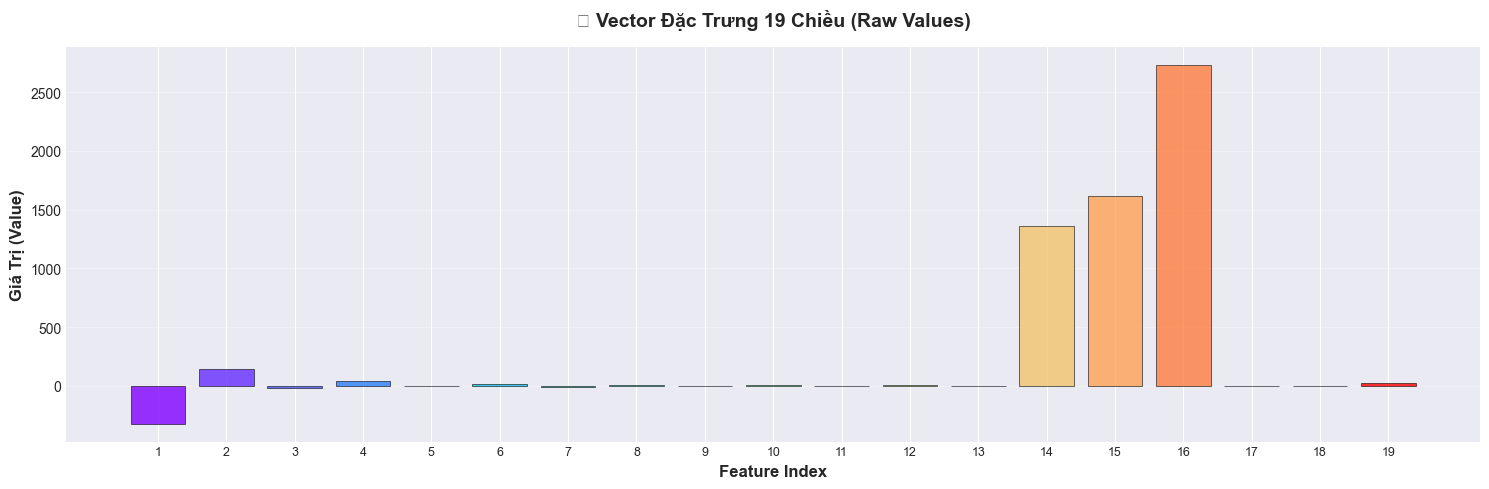

In [7]:
# Visualize feature vector
fig, ax = plt.subplots(figsize=(15, 5))

colors = plt.cm.rainbow(np.linspace(0, 1, len(FEATURE_NAMES)))
bars = ax.bar(range(len(FEATURE_NAMES)), raw_feature_vector, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Feature Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá Trị (Value)', fontsize=12, fontweight='bold')
ax.set_title('📊 Vector Đặc Trưng 19 Chiều (Raw Values)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([f'{i+1}' for i in range(len(FEATURE_NAMES))], fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Chuẩn hóa Vector (Z-score Normalization)

Công thức chuẩn hóa: `x_normalized = (x - mean) / std`

Mục đích: Đưa mỗi feature về phân phối chuẩn (mean=0, std=1) để tính Cosine Distance chính xác hơn.

In [8]:
# Load scaler parameters
scaler_csv_path = "/Users/nangvuong/Desktop/BTL_CSDLDPT/audio-feature-extractor/scaler_params.csv"
scaler_params = {}

with open(scaler_csv_path, 'r', newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)  # Skip header
    for row in reader:
        feature_name = row[0]
        mean_val = float(row[1])
        std_val = float(row[2])
        scaler_params[feature_name] = (mean_val, std_val)

print(f"✅ Loaded scaler parameters for {len(scaler_params)} features")

# Apply normalization
normalized_vector = raw_feature_vector.copy()
for i, name in enumerate(FEATURE_NAMES):
    if name in scaler_params:
        mean_val, std_val = scaler_params[name]
        if std_val != 0:
            normalized_vector[i] = (raw_feature_vector[i] - mean_val) / std_val

print(f"\n📋 Vector Sau Chuẩn Hóa (Normalized):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"   {i+1:2d}. {name:25s} = {normalized_vector[i]:12.6f}")

print(f"\n✅ Thống kê Vector Chuẩn Hóa:")
print(f"   - Mean: {normalized_vector.mean():.6f}")
print(f"   - Std:  {normalized_vector.std():.6f}")
print(f"   - Min:  {normalized_vector.min():.6f}")
print(f"   - Max:  {normalized_vector.max():.6f}")

✅ Loaded scaler parameters for 19 features

📋 Vector Sau Chuẩn Hóa (Normalized):
    1. mfcc_1                    =    -0.546178
    2. mfcc_2                    =     0.596103
    3. mfcc_3                    =    -0.427727
    4. mfcc_4                    =     0.841373
    5. mfcc_5                    =    -0.256078
    6. mfcc_6                    =     0.821681
    7. mfcc_7                    =    -0.356288
    8. mfcc_8                    =     1.039215
    9. mfcc_9                    =     0.641700
   10. mfcc_10                   =     1.032061
   11. mfcc_11                   =     1.108781
   12. mfcc_12                   =     0.693123
   13. mfcc_13                   =     0.860138
   14. spectral_centroid         =    -0.378016
   15. spectral_bandwidth        =    -0.423291
   16. spectral_rolloff          =    -0.299390
   17. zero_crossing_rate        =    -0.059259
   18. rms_energy                =    -0.839881
   19. spectral_contrast         =     0.298941

✅ Thốn

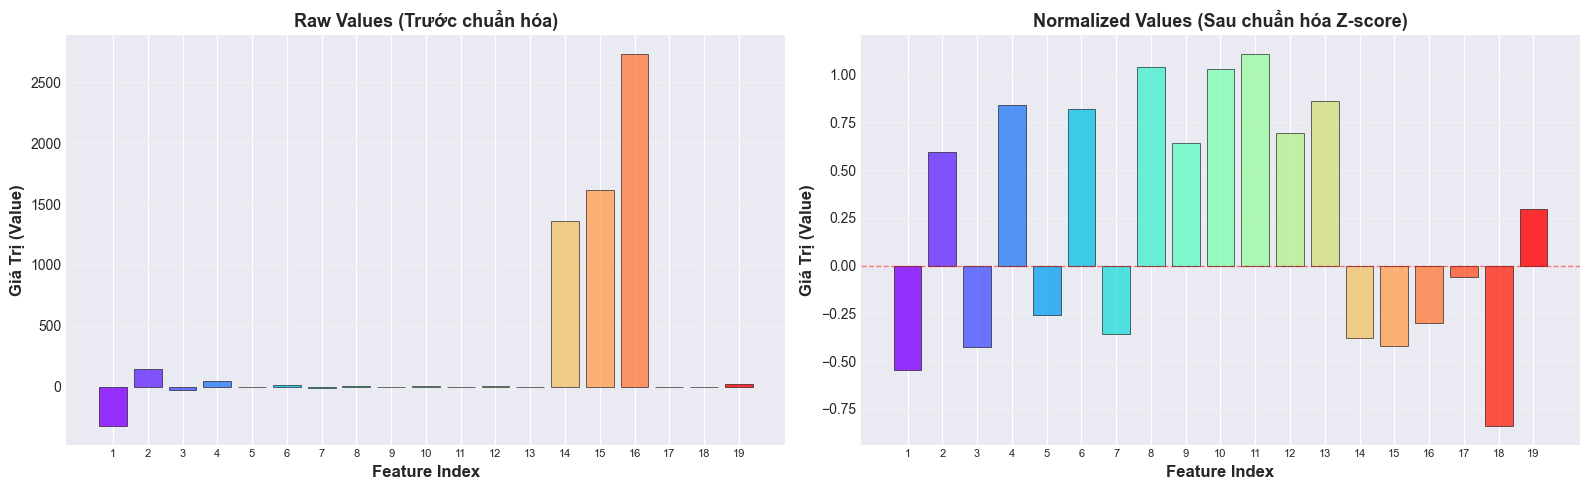

In [9]:
# So sánh Raw vs Normalized
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = plt.cm.rainbow(np.linspace(0, 1, len(FEATURE_NAMES)))

# Raw
axes[0].bar(range(len(FEATURE_NAMES)), raw_feature_vector, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Feature Index', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Giá Trị (Value)', fontsize=12, fontweight='bold')
axes[0].set_title('Raw Values (Trước chuẩn hóa)', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(FEATURE_NAMES)))
axes[0].set_xticklabels([f'{i+1}' for i in range(len(FEATURE_NAMES))], fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Normalized
axes[1].bar(range(len(FEATURE_NAMES)), normalized_vector, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Feature Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Giá Trị (Value)', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized Values (Sau chuẩn hóa Z-score)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(FEATURE_NAMES)))
axes[1].set_xticklabels([f'{i+1}' for i in range(len(FEATURE_NAMES))], fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 6.4.4 Giá Trị Cosine Similarity - Tính Độ Tương Đồng Với Database

In [10]:
# Load normalized database vectors
db_csv_path = "/Users/nangvuong/Desktop/BTL_CSDLDPT/audio-feature-extractor/audio_features_normalized.csv"

db_data = pd.read_csv(db_csv_path)

print(f"✅ Loaded database with {len(db_data)} records")
print(f"\nDatabase columns: {db_data.columns.tolist()}")
print(f"\nDatabase info:")
print(db_data.head())

✅ Loaded database with 524 records

Database columns: ['mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'zero_crossing_rate', 'rms_energy', 'spectral_contrast', 'instrument', 'filename']

Database info:
     mfcc_1    mfcc_2    mfcc_3    mfcc_4    mfcc_5    mfcc_6    mfcc_7  \
0  0.317743 -1.004601  0.443645  0.992212 -0.734258  0.245164  0.655446   
1  0.349500 -0.996674  0.496432  0.612085 -1.188409  0.723587  0.218679   
2  0.125335  0.359757  0.569783 -0.045419 -0.298416  0.251894  0.239244   
3 -0.481499  0.337710  0.758238  0.153470  0.369528  0.728048  1.599758   
4  0.561876  1.160448 -0.537569 -0.493493  1.072578 -0.456804 -0.563297   

     mfcc_8    mfcc_9   mfcc_10  ...   mfcc_12   mfcc_13  spectral_centroid  \
0  1.228849 -1.389244 -1.107023  ... -0.111486  0.233248           0.630455   
1 -0.114460 -0.674512  0.756751  ...  0.

In [11]:
# Calculate Cosine Distance (1 - Cosine Similarity)
# Cosine Distance = 1 - cos(θ), where cos(θ) is cosine similarity
# Smaller distance = more similar

distances = []

# Extract feature vectors from database (columns 0-18)
db_vectors = db_data.iloc[:, :19].values

for db_vector in db_vectors:
    # Cosine distance using 1 - cosine similarity
    dist = 1 - (np.dot(normalized_vector, db_vector) / 
                (np.linalg.norm(normalized_vector) * np.linalg.norm(db_vector) + 1e-10))
    distances.append(dist)

# Add distances to dataframe
db_data['distance'] = distances

# Sort by distance and get top 5
top_5 = db_data.nsmallest(5, 'distance')[['instrument', 'filename', 'distance']]

print(f"✅ Tính Cosine Distance thành công!")
print(f"\n🏆 Top 5 Kết Quả Tương Đồng Nhất:\n")
print(top_5.to_string(index=False))

# Statistics
print(f"\n📊 Thống kê Cosine Distance:")
print(f"   - Min: {db_data['distance'].min():.6f}")
print(f"   - Max: {db_data['distance'].max():.6f}")
print(f"   - Mean: {db_data['distance'].mean():.6f}")
print(f"   - Median: {db_data['distance'].median():.6f}")

✅ Tính Cosine Distance thành công!

🏆 Top 5 Kết Quả Tương Đồng Nhất:

instrument                        filename  distance
    violin 007__[vio][nod][cla]2103__3.wav  0.014605
    violin 007__[vio][nod][cla]2103__2.wav  0.217034
    violin 126__[vio][nod][cla]2185__3.wav  0.251297
    violin 044__[vio][nod][cla]2186__1.wav  0.261232
    violin 126__[vio][nod][cla]2185__1.wav  0.277984

📊 Thống kê Cosine Distance:
   - Min: 0.014605
   - Max: 1.723917
   - Mean: 0.986616
   - Median: 1.006660


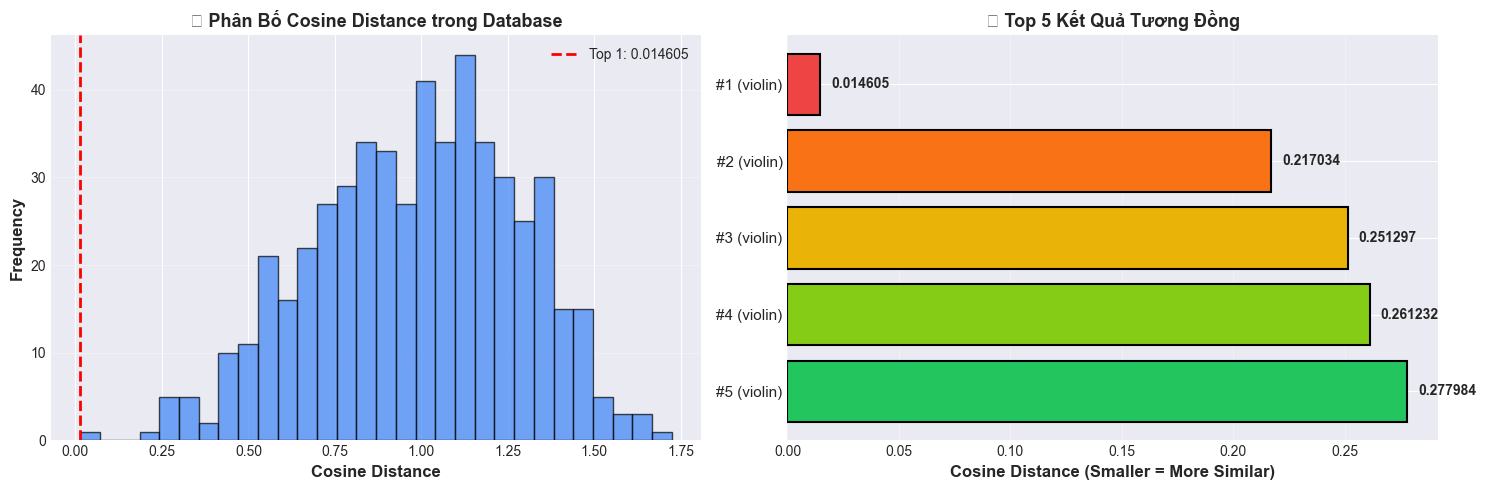

In [12]:
# Visualize Cosine Distance Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(db_data['distance'], bins=30, color='#3B82F6', alpha=0.7, edgecolor='black')
axes[0].axvline(top_5['distance'].iloc[0], color='red', linestyle='--', linewidth=2, label=f'Top 1: {top_5["distance"].iloc[0]:.6f}')
axes[0].set_xlabel('Cosine Distance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('📊 Phân Bố Cosine Distance trong Database', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Top 5 Bar Chart
colors_top5 = ['#EF4444', '#F97316', '#EAB308', '#84CC16', '#22C55E']
axes[1].barh(range(5), top_5['distance'].values[::-1], color=colors_top5[::-1], edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(5))
axes[1].set_yticklabels([f"#{i+1} ({top_5['instrument'].iloc[i]})" for i in range(4, -1, -1)], fontsize=11)
axes[1].set_xlabel('Cosine Distance (Smaller = More Similar)', fontsize=12, fontweight='bold')
axes[1].set_title('🏆 Top 5 Kết Quả Tương Đồng', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(top_5['distance'].values[::-1]):
    axes[1].text(v + 0.005, i, f'{v:.6f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Detailed Results Table
print("=" * 80)
print("🏆 KẾT QUẢ CHI TIẾT - DETAILED RESULTS")
print("=" * 80)

for rank, (idx, row) in enumerate(top_5.iterrows(), 1):
    similarity_pct = max(0, (1 - row['distance']) * 100)
    print(f"\n#{rank} | Instrument: {row['instrument']:20s} | Similarity: {similarity_pct:6.2f}%")
    print(f"     File: {row['filename']}")
    print(f"     Cosine Distance: {row['distance']:.6f}")
    print(f"     {'-'*70}")

# Summary statistics
print(f"\n\n📊 PHÂN TÍCH TỔNG HỢP:")
print(f"   - Query vector chuẩn hóa (normalized)")
print(f"   - So sánh với {len(db_data)} vectors trong database")
print(f"   - Khoảng cách Cosine: từ {db_data['distance'].min():.6f} đến {db_data['distance'].max():.6f}")
print(f"   - Top 1 kết quả: {top_5['distance'].iloc[0]:.6f} ({max(0, (1-top_5['distance'].iloc[0])*100):.2f}% similarity)")
print(f"   - Top 5 trung bình: {top_5['distance'].mean():.6f}")
print("=" * 80)

🏆 KẾT QUẢ CHI TIẾT - DETAILED RESULTS

#1 | Instrument: violin               | Similarity:  98.54%
     File: 007__[vio][nod][cla]2103__3.wav
     Cosine Distance: 0.014605
     ----------------------------------------------------------------------

#2 | Instrument: violin               | Similarity:  78.30%
     File: 007__[vio][nod][cla]2103__2.wav
     Cosine Distance: 0.217034
     ----------------------------------------------------------------------

#3 | Instrument: violin               | Similarity:  74.87%
     File: 126__[vio][nod][cla]2185__3.wav
     Cosine Distance: 0.251297
     ----------------------------------------------------------------------

#4 | Instrument: violin               | Similarity:  73.88%
     File: 044__[vio][nod][cla]2186__1.wav
     Cosine Distance: 0.261232
     ----------------------------------------------------------------------

#5 | Instrument: violin               | Similarity:  72.20%
     File: 126__[vio][nod][cla]2185__1.wav
     Cosine Di

---

## 📝 Tóm Tắt Quy Trình Truy Vấn

### Các Bước Thực Hiện:

1. **Waveform (6.4.1)**: 
   - Tải file âm thanh `.wav` với sample rate 22050 Hz
   - Hiển thị biểu đồ sóng âm thanh theo thời gian

2. **Spectrogram (6.4.2)**:
   - Tính toán STFT (Short-Time Fourier Transform) 
   - Chuyển đổi sang Mel-scale (128 mel-bins)
   - Hiển thị phổ tần số theo thời gian dưới dạng heatmap

3. **Feature Vector (6.4.3)**:
   - Trích xuất 19 đặc trưng từ audio:
     - **13 MFCC**: Đại diện cho âm sắc (timbre)
     - **Spectral Centroid**: Độ sáng phổ
     - **Spectral Bandwidth**: Độ rộng phổ
     - **Spectral Rolloff**: Tần số mà 85% năng lượng nằm dưới
     - **Zero Crossing Rate**: Phân biệt âm trầm/cao
     - **RMS Energy**: Độ to (loudness)
     - **Spectral Contrast**: Tương phản phổ
   - Chuẩn hóa vector bằng Z-score normalization

4. **Cosine Similarity (6.4.4)**:
   - Tính Cosine Distance giữa query vector và tất cả vectors trong database
   - Sắp xếp theo khoảng cách nhỏ nhất
   - Trả về Top 5 kết quả tương đồng nhất

### Công Thức Chính:

**Cosine Distance** = $1 - \cos(\theta) = 1 - \frac{\vec{A} \cdot \vec{B}}{||\vec{A}|| \times ||\vec{B}||}$

- Giá trị từ 0 (giống hệt) đến 2 (khác biệt tối đa)
- Nhỏ hơn = Tương đồng hơn

---

## 🔧 Chi Tiết Kỹ Thuật

### Stack Công Nghệ:
- **Backend**: Go (Fiber framework)
- **Database**: PostgreSQL + pgvector extension
- **Audio Processing**: Python (librosa, scipy)
- **Feature Extraction**: 19-dimensional vector (MFCC + Spectral features)
- **Similarity Search**: Cosine Distance (có thể optimize với HNSW index)

### Quy Trình Backend:

```
1. User uploads audio file (.wav)
   ↓
2. Backend saves temp file
   ↓
3. Call Python script (extract_single.py)
   ↓
4. Extract features + Load scaler params + Normalize
   ↓
5. Query PostgreSQL:
   SELECT * FROM audio_features 
   ORDER BY feature_vector <=> query_vector
   LIMIT 5
   ↓
6. Return top 5 results with cosine distance scores
   ↓
7. Frontend displays results + audio players
```

### Tối Ưu Hiệu Năng:
- ✅ Vector đã chuẩn hóa (Z-score)
- ✅ Sử dụng Cosine Distance (phù hợp với normalized vectors)
- ⏳ Có thể thêm HNSW index trên PostgreSQL để ANN search